# UWB LOS/NLOS Classification & Distance Estimation — Exploratory Data Analysis
**Course:** CSC3105 Data Analytics and AI  
**Dataset:** UWB-LOS-NLOS-Dataset (Decawave DWM1000, 42,000 samples, 7 indoor environments)  

---

## Overview
This juypter notebook is a breakdown of the exploratory data analysis the team has done to understand the dataset provided and find for important features for modelling usage. At the end of this exploratory, a new dataset file will be created which would be used as the import file for the Machine Learning models.

## 1. Imports

Standard data science stack: `pandas` for data manipulation, `seaborn`/`matplotlib` for visualisation, `scipy` for statistical measures (kurtosis, skewness). Warnings are suppressed for cleaner notebook output.

In [1]:
# Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from scipy.stats import kurtosis, skew
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 120)
pd.set_option('display.max_colwidth', None)

In [2]:
# Paths
BASE_DIR = Path(".")
DATASET_DIR = BASE_DIR / "Dataset" / "UWB-LOS-NLOS-Data-Set" / "dataset"

# Print this to find location of dataset
# print(f"\nDataset: {DATASET_DIR.absolute()}")

## 2. Load and Merge Dataset

The dataset is distributed across 7 CSV files (`uwb_dataset_part1.csv` … `part7.csv`). Per the eWINE dataset README, these files are **randomised shuffled splits** of the full 42,000-sample collection — not per-room splits. Each file contains approximately equal proportions of LOS and NLOS samples drawn randomly from all 7 indoor environments. We merge them into a single DataFrame and add a `dataset_part` column for traceability.

In [3]:
all_files = list(DATASET_DIR.glob("*.csv"))

dataframes = []
for i, file in enumerate(all_files):
    print(f"  Loading {i+1}/{len(all_files)}: {file.name}...", end='\r')
    df_temp = pd.read_csv(file)
    df_temp['dataset_part'] = file.stem
    dataframes.append(df_temp)

df_raw = pd.concat(dataframes, ignore_index=True)
print(f"Done — {len(df_raw):,} rows from {len(all_files)} files loaded.   ")

Done — 42,000 rows from 7 files loaded.   


## 3. Dataset Structure

The dataset has **1,032 columns** in total. We separate them into three groups for focused exploration:

| Group | Columns | Description |
|---|---|---|
| **Label** | `NLOS` | Binary target: 0 = LOS, 1 = NLOS |
| **Metadata** | 14 features | DW1000 hardware measurements: range, first-path amplitudes, noise metrics, preamble statistics |
| **CIR** | 1,016 columns (`CIR0`–`CIR1015`) | Channel Impulse Response amplitude at 1 ns intervals |
| **Other** | `dataset_part` | Source file identifier — used for traceability only |

The `df_raw.head()` below shows the first few rows, confirming the column layout.

In [4]:
display(pd.DataFrame({
    'Metric': ['Total rows', 'Total columns', 'Metadata features', 'CIR columns', 'float64 columns', 'int64 columns'],
    'Value': [
        f"{df_raw.shape[0]:,}",
        df_raw.shape[1],
        14,
        sum(1 for c in df_raw.columns if c.startswith('CIR') and c[3:].isdigit()),
        (df_raw.dtypes == 'float64').sum(),
        (df_raw.dtypes == 'int64').sum(),
    ]
}))

df_raw.head()

,Metric,Value
0,Total rows,"42,000"
1,Total columns,1032
2,Metadata features,14
3,CIR columns,1016
4,float64 columns,1031
5,int64 columns,0


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,CH,FRAME_LEN,PREAM_LEN,BITRATE,PRFR,CIR0,CIR1,CIR2,CIR3,CIR4,CIR5,CIR6,CIR7,CIR8,CIR9,CIR10,CIR11,CIR12,CIR13,CIR14,CIR15,CIR16,CIR17,CIR18,CIR19,CIR20,CIR21,CIR22,CIR23,CIR24,CIR25,CIR26,CIR27,CIR28,CIR29,CIR30,CIR31,CIR32,CIR33,CIR34,CIR35,CIR36,CIR37,CIR38,CIR39,CIR40,CIR41,CIR42,CIR43,CIR44,...,CIR957,CIR958,CIR959,CIR960,CIR961,CIR962,CIR963,CIR964,CIR965,CIR966,CIR967,CIR968,CIR969,CIR970,CIR971,CIR972,CIR973,CIR974,CIR975,CIR976,CIR977,CIR978,CIR979,CIR980,CIR981,CIR982,CIR983,CIR984,CIR985,CIR986,CIR987,CIR988,CIR989,CIR990,CIR991,CIR992,CIR993,CIR994,CIR995,CIR996,CIR997,CIR998,CIR999,CIR1000,CIR1001,CIR1002,CIR1003,CIR1004,CIR1005,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015,dataset_part
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,2.0,39.0,1024.0,110.0,64.0,129.0,312.0,331.0,141.0,160.0,488.0,195.0,144.0,119.0,193.0,158.0,192.0,120.0,35.0,295.0,111.0,292.0,170.0,84.0,107.0,293.0,200.0,333.0,450.0,241.0,162.0,97.0,449.0,146.0,66.0,165.0,455.0,190.0,142.0,218.0,280.0,219.0,238.0,265.0,207.0,123.0,164.0,195.0,322.0,222.0,...,130.0,256.0,199.0,200.0,183.0,278.0,432.0,211.0,263.0,105.0,402.0,320.0,133.0,170.0,207.0,280.0,399.0,457.0,162.0,329.0,162.0,325.0,121.0,110.0,291.0,301.0,259.0,251.0,156.0,200.0,287.0,177.0,402.0,216.0,242.0,249.0,420.0,306.0,86.0,278.0,487.0,445.0,169.0,243.0,425.0,235.0,164.0,297.0,114.0,279.0,458.0,183.0,158.0,198.0,87.0,296.0,505.0,307.0,0.0,uwb_dataset_part1
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,2.0,27.0,1024.0,110.0,64.0,117.0,163.0,199.0,136.0,142.0,182.0,358.0,123.0,280.0,311.0,236.0,166.0,240.0,286.0,117.0,242.0,250.0,318.0,204.0,259.0,82.0,207.0,145.0,255.0,201.0,179.0,255.0,50.0,201.0,184.0,178.0,279.0,99.0,289.0,190.0,93.0,289.0,329.0,164.0,132.0,145.0,195.0,131.0,76.0,85.0,...,202.0,285.0,151.0,254.0,200.0,122.0,81.0,223.0,75.0,174.0,263.0,249.0,148.0,187.0,229.0,172.0,107.0,65.0,338.0,147.0,51.0,283.0,255.0,322.0,311.0,159.0,330.0,194.0,57.0,148.0,123.0,149.0,62.0,60.0,379.0,196.0,140.0,90.0,177.0,257.0,277.0,87.0,473.0,277.0,107.0,104.0,161.0,168.0,196.0,144.0,334.0,290.0,228.0,187.0,213.0,202.0,89.0,103.0,0.0,uwb_dataset_part1
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,2.0,27.0,1024.0,110.0,64.0,433.0,240.0,233.0,81.0,143.0,506.0,119.0,272.0,248.0,233.0,233.0,95.0,255.0,189.0,142.0,274.0,131.0,253.0,115.0,102.0,50.0,417.0,239.0,40.0,218.0,161.0,235.0,165.0,153.0,262.0,146.0,240.0,258.0,101.0,228.0,204.0,147.0,130.0,201.0,285.0,209.0,168.0,115.0,246.0,274.0,...,310.0,95.0,92.0,222.0,209.0,373.0,303.0,69.0,196.0,180.0,127.0,129.0,103.0,302.0,264.0,262.0,266.0,199.0,202.0,192.0,280.0,31.0,200.0,234.0,122.0,445.0,89.0,329.0,288.0,139.0,160.0,217.0,550.0,215.0,257.0,217.0,279.0,30.0,314.0,234.0,138.0,196.0,264.0,251.0,83.0,154.0,82.0,324.0,208.0,32.0,373.0,224.0,174.0,124.0,329.0,207.0,96.0,218.0,0.0,uwb_dataset_part1
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,2.0,39.0,1024.0,110.0,64.0,466.0,247.0,407.0,225.0,279.0,69.0,393.0,436.0,289.0,169.0,308.0,233.0,177.0,398.0,500.0,71.0,291.0,194.0,408.0,282.0,182.0,293.0,194.0,352.0,467.0,194.0,258.0,164.0,442.0,126.0,359.0,517.0,199.0,211.0,214.0,127.0,151.0,201.0,295.0,94.0,201.0,248.0,246.0,53.0,418.0,...,282.0,138.0,334.0,60.0,152.0,484.0,370.0,347.0,136.0,195.0,233.0,322.0,473.0,487.0,380.0,266.0,299.0,141.0,195.0,319.0,146.0,246.0,218.0,163.0,332.0,155.0,269.0,291.0,395.0,189.0,81.0,121.0,195.0,261.0,534.0,193.0,34.0,214.0,451.0,421.0,231.0,263.0,248.0,381.0,224.0,372.0,483.0,125.0,210.0,252.0,173.0,198.0,160.0,434.0,397.0,290.0,155.0,342.0,256.0,uwb_dataset_part1
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,2.0,27.0,1024.0,110.0,64.0,259.0,239.0,57.0,19.0,88.0,219.0,400.0,151.0,98.0,415.0,144.0,130.0,106.0,216.0,239.0,112.0,121.0,466.0,74.0,315.0,255.0,281.0,392.0,132.0,129.0,216.0,151.0,266.0,295.0,212.0,391.0,25

In [5]:
target_col = "NLOS"

# Separate metadata columns and CIR columns for easier and manageable data exploration
# signal statistics
metadata_cols = [
    "RANGE", "FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3",
    "STDEV_NOISE", "CIR_PWR", "MAX_NOISE", "RXPACC",
    "CH", "FRAME_LEN", "PREAM_LEN", "BITRATE", "PRFR"
]

# Only raw Channel Impulse Response (CIR) waveform columns: CIR0 ... CIR1015
cir_cols = sorted(
    [col for col in df_raw.columns if col.startswith("CIR") and col[3:].isdigit()],
    key=lambda x: int(x[3:])
)

## 4. Data Quality Check

Before any analysis, we verify completeness and integrity. **Missing values** would silently propagate through calculations (e.g., a NaN in a CIR column would corrupt mean/std statistics). **Duplicate rows** would artificially inflate certain samples in training, biasing model learning.

The DW1000 hardware always populates every output register, so we expect zero missing values — but we verify rather than assume.

In [6]:
missing_counts = df_raw.isna().sum()
missing_nonzero = missing_counts[missing_counts > 0].sort_values(ascending=False)
duplicate_count = df_raw.duplicated().sum()

display(pd.DataFrame({
    'Check': ['Missing values (total)', 'Columns with any missing', 'Duplicate rows'],
    'Result': [missing_counts.sum(), len(missing_nonzero), duplicate_count],
    'Status': [
        '✅ Clean' if missing_counts.sum() == 0 else '⚠️ Found',
        '✅ None'  if len(missing_nonzero) == 0 else '⚠️ Found',
        '✅ None'  if duplicate_count == 0 else '⚠️ Found',
    ]
}))

,Check,Result,Status
0,Missing values (total),0,✅ Clean
1,Columns with any missing,0,✅ None
2,Duplicate rows,0,✅ None


Both quality checks pass. The statistical summary below covers the first 20 columns — it confirms the value ranges and reveals that `CH`, `BITRATE`, and `PRFR` have zero variance (std = 0, min = max), which will be addressed during preprocessing.

In [7]:
summary_table = df_raw.describe(include="all").T
summary_table.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
NLOS,42000.0,NaN,NaN,NaN,0.5,0.500006,0.0,0.0,0.5,1.0,1.0
RANGE,42000.0,NaN,NaN,NaN,3.831519,2.355976,0.0,1.81,3.48,5.42,28.02
FP_IDX,42000.0,NaN,NaN,NaN,745.654167,4.505024,707.0,744.0,746.0,748.0,848.0
FP_AMP1,42000.0,NaN,NaN,NaN,8127.521905,5393.330697,7.0,3573.75,7140.0,12273.0,20572.0
FP_AMP2,42000.0,NaN,NaN,NaN,11425.259524,6235.434769,63.0,5322.75,12318.0,17310.0,20624.0
FP_AMP3,42000.0,NaN,NaN,NaN,9738.106048,5352.311549,187.0,4723.0,10262.0,14256.0,20577.0
STDEV_NOISE,42000.0,NaN,NaN,NaN,72.284571,29.318995,28.0,56.0,68.0,80.0,324.0
CIR_PWR,42000.0,NaN,NaN,NaN,9789.690214,4912.556005,0.0,6727.0,9950.5,12443.0,37208.0
MAX_NOISE,42000.0,NaN,NaN,NaN,1316.096524,582.434989,310.0,961.0,1134.0,1488.0,5169.0
RXPACC,42000.0,NaN,NaN,NaN,616.2725,306.78537,128.0,318.0,513.0,1024.0,1056.0


## 5. Target / Class Exploration

We first inspect the class distribution of the target variable `NLOS`. A **balanced dataset** (equal LOS and NLOS samples) is important: class imbalance would bias models toward the majority class, inflating accuracy while the minority class is poorly learned. The project brief confirms 21,000 LOS and 21,000 NLOS samples across 7 environments.

In [8]:
class_counts = df_raw[target_col].value_counts().sort_index()
class_counts

NLOS
0.0    21000
1.0    21000
Name: count, dtype: int64

The counts confirm perfect balance. We map the binary labels to readable strings (`LOS`/`NLOS`) for all subsequent visualisations.

In [9]:
# Making clearer labels for analysis
df_raw["class_label"] = df_raw[target_col].map({0: "LOS", 1:"NLOS"})

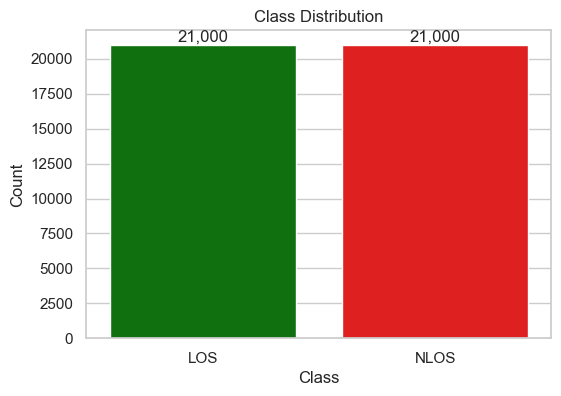

In [10]:
# Class distribution plot
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df_raw, x="class_label", hue="class_label", palette=["green", "red"], legend=False)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
               (p.get_x() + p.get_width() / 2, p.get_height()),
               ha="center", va="bottom")
    
plt.savefig('results/figures/eda/01_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

The bar chart confirms equal class distribution — no resampling is needed. The plot below checks the sample counts per source CSV file to verify that each of the 7 dataset parts contributes equally.

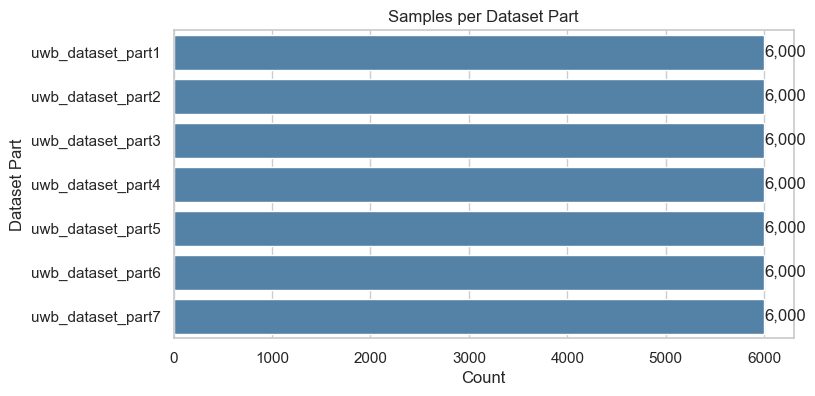

In [11]:
# Samples per source file
plt.figure(figsize=(8,4))
ax = sns.countplot(data=df_raw, y="dataset_part", order=sorted(df_raw["dataset_part"].unique()), color="steelblue")
plt.title("Samples per Dataset Part")
plt.xlabel("Count")
plt.ylabel("Dataset Part")

for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}",
               (p.get_width(), p.get_y() + p.get_height()/ 2),
               ha="left", va="center")

plt.savefig('results/figures/eda/02_samples_per_dataset_part.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Metadata Feature Exploration

The 14 metadata features are hardware-measured properties of the DW1000 radio. Their distributions reveal which features vary meaningfully across samples and which are constants (candidates for removal). We use histograms for shape and density plots for class-conditional comparison.

Note that `CH`, `BITRATE`, and `PRFR` appear constant — fixed hardware configuration parameters. These will be dropped during preprocessing as they carry zero information.

In [12]:
metadata_summary = df_raw[metadata_cols].describe().T
metadata_summary

,count,mean,std,min,25%,50%,75%,max
RANGE,42000.0,3.831519,2.355976,0.0,1.81,3.48,5.42,28.02
FP_IDX,42000.0,745.654167,4.505024,707.0,744.00,746.00,748.00,848.00
FP_AMP1,42000.0,8127.521905,5393.330697,7.0,3573.75,7140.00,12273.00,20572.00
FP_AMP2,42000.0,11425.259524,6235.434769,63.0,5322.75,12318.00,17310.00,20624.00
FP_AMP3,42000.0,9738.106048,5352.311549,187.0,4723.00,10262.00,14256.00,20577.00
STDEV_NOISE,42000.0,72.284571,29.318995,28.0,56.00,68.00,80.00,324.00
CIR_PWR,42000.0,9789.690214,4912.556005,0.0,6727.00,9950.50,12443.00,37208.00
MAX_NOISE,42000.0,1316.096524,582.434989,310.0,961.00,1134.00,1488.00,5169.00
RXPACC,42000.0,616.272500,306.785370,128.0,318.00,513.00,1024.00,1056.00
CH,42000.0,2.000000,0.000000,2.0,2.00,2.00,2.00,2.00


The histograms confirm that `CH`, `BITRATE`, and `PRFR` are single-spike distributions (zero variance). The remaining features show meaningful spread. The box plots and density plots below reveal how these distributions *differ between LOS and NLOS classes* — the key question for classification.

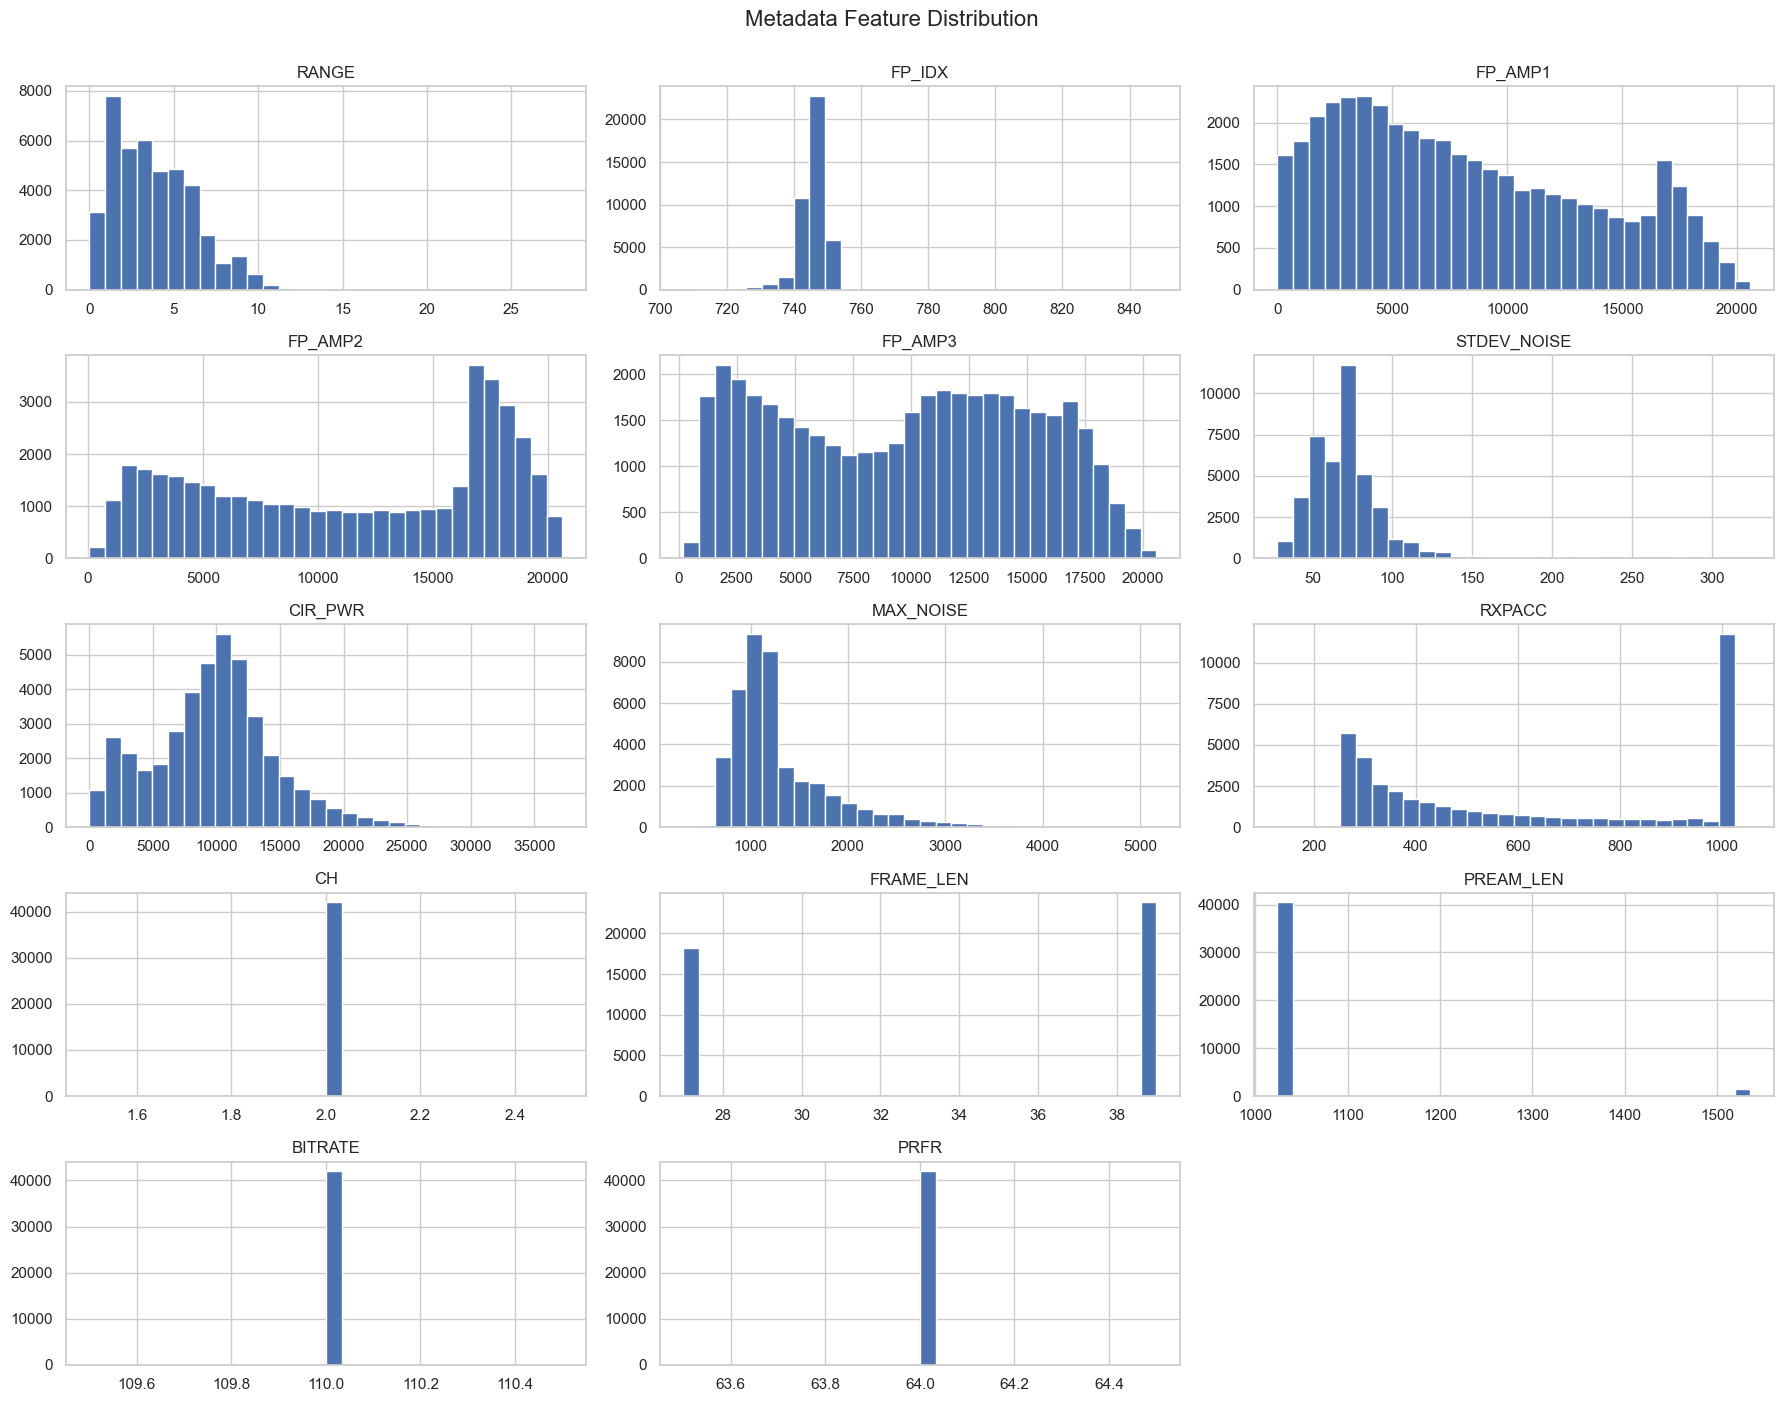

In [13]:
df_raw[metadata_cols].hist(bins=30, figsize=(18, 14), layout=(5, 3))
plt.suptitle("Metadata Feature Distribution", y=1, fontsize = 16)
plt.tight_layout()
plt.savefig('results/figures/eda/03_metadata_feature_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Metadata vs Target Exploration
This section investigates how metadata features differ between LOS and NLOS samples. Kernel density plots were used to visualize the distributions of each feature for both classes.

### Findings
- Noise-related features such as **STDEV_NOISE** and **MAX_NOISE** tend to have higher values for NLOS samples, suggesting that obstructed signals introduce additional noise and signal variation.
- Signal amplitude features (**FP_AMP1–FP_AMP3**) generally appear stronger for LOS samples, reflecting the presence of a direct signal path.
- These differences indicate that metadata features may contain useful information for distinguishing LOS and NLOS conditions.

### Physical & Mathematical Explanation
- **Why is STDEV_NOISE higher for NLOS?** In NLOS, the direct path is blocked, so energy arrives via multiple reflected paths (multipath propagation). Each reflected copy arrives at a slightly different time, and the receiver accumulates these overlapping signals. Their constructive and destructive interference raises the noise floor — mathematically, the received signal $r(t) = \sum_i \alpha_i s(t - \tau_i) + n(t)$ has higher variance when there are many components $i$ with different delays $\tau_i$.

- **Why are FP_AMP values lower for NLOS?** The first-path amplitudes (FP_AMP1–3) measure the signal strength of the direct path at three points around the first detected peak. In NLOS, the direct path must travel through or diffract around an obstacle, losing energy proportional to the material's absorption and scattering coefficients. The received power follows an inverse square law plus an attenuation term: $P_r \propto P_t \cdot \frac{G}{d^2} \cdot e^{-\mu d}$, where $\mu$ is the material's attenuation factor. This explains why NLOS first-path amplitudes are systematically weaker.

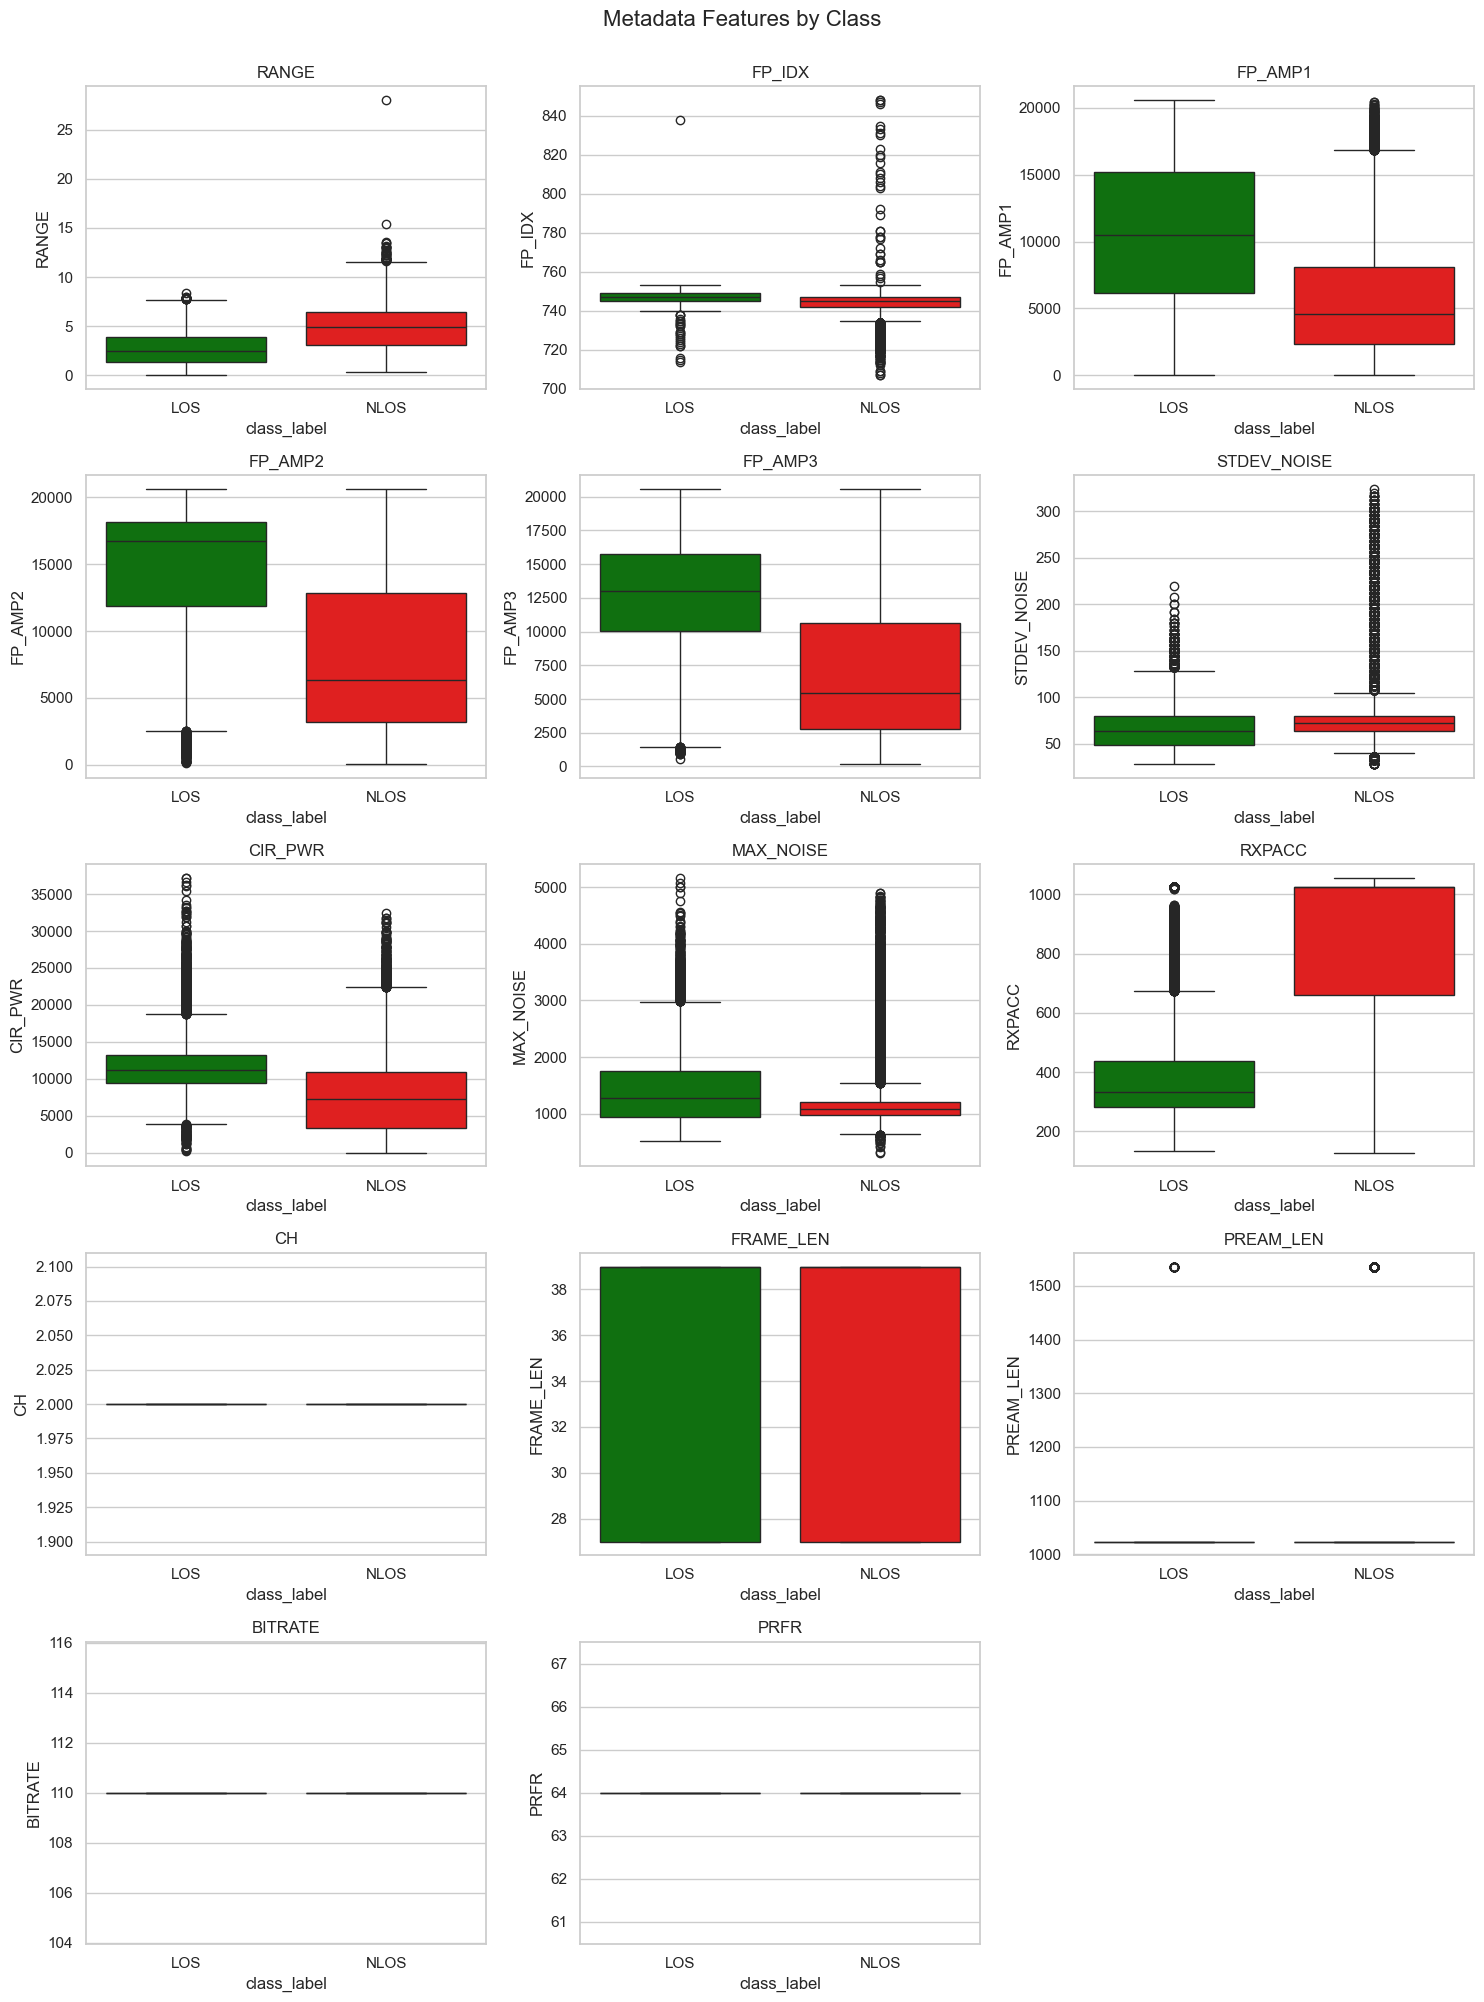

In [14]:
n_cols = 3
n_rows = int(np.ceil(len(metadata_cols)/n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(metadata_cols):

    sns.boxplot(
        data=df_raw,
        x="class_label",
        hue="class_label", 
        palette=["green", "red"],
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Metadata Features by Class", y=1, fontsize=16)
plt.tight_layout()
plt.savefig('results/figures/eda/04_metadata_feature_by_class.png', dpi=120, bbox_inches='tight')
plt.show()

The box plots show clear class-conditional differences for several features. The kernel density plots below provide a smoother view, making it easier to assess the degree of overlap between LOS and NLOS distributions — overlap is unavoidable, which is precisely why we need machine learning rather than simple thresholds.

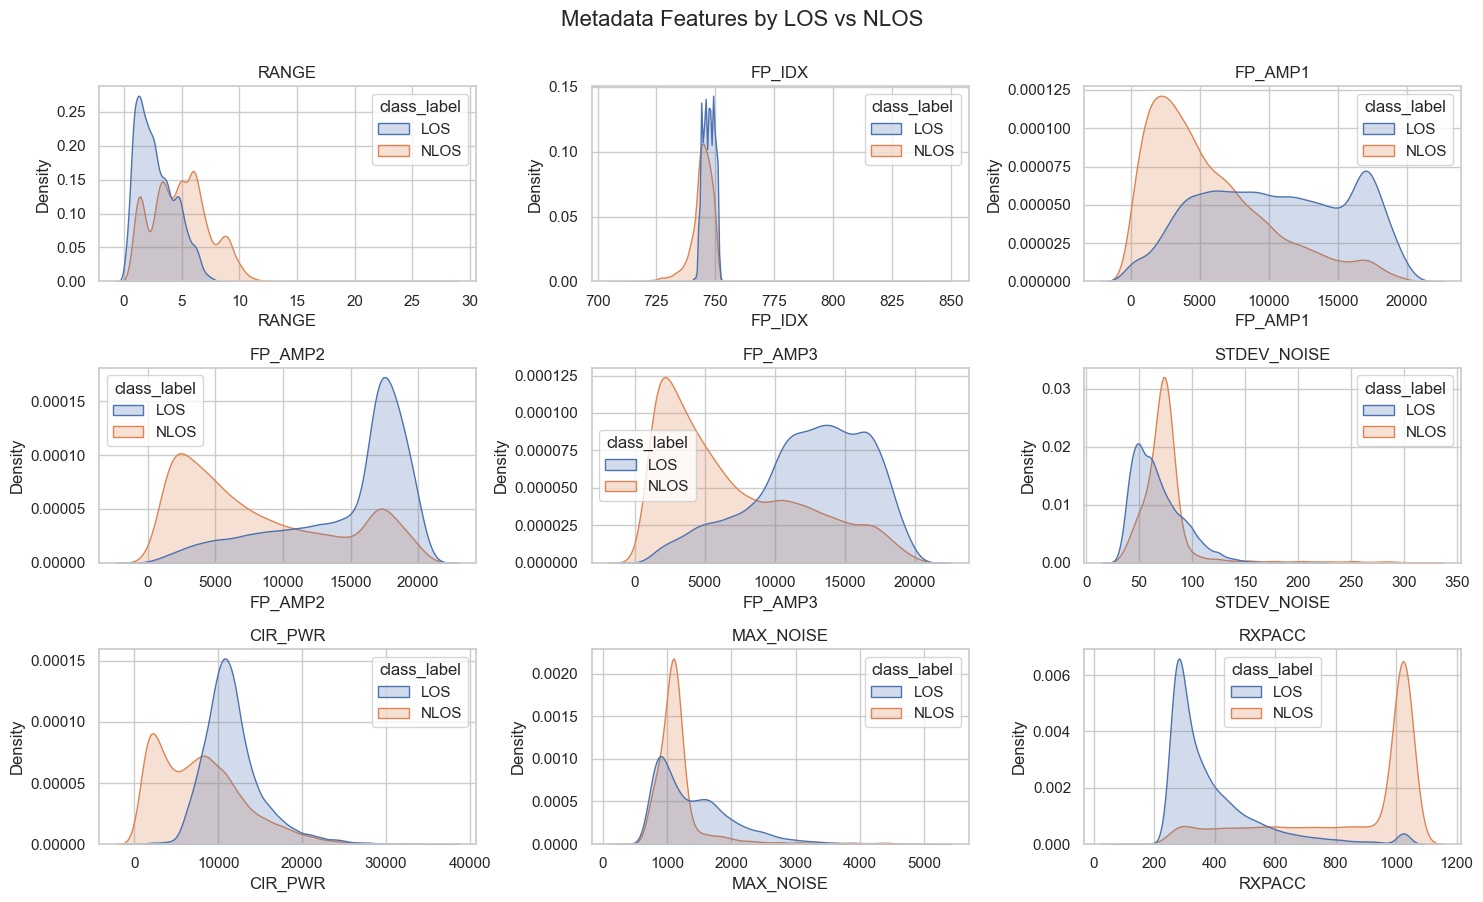

In [15]:
# Density Plot
key_features = ["RANGE", "FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3", "STDEV_NOISE", "CIR_PWR", "MAX_NOISE", "RXPACC"]

n_rows = int(np.ceil(len(key_features)/n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))

axes = axes.flatten()

for i, col in enumerate(key_features):
    
    sns.kdeplot(
        data=df_raw,
        x=col,
        hue="class_label",
        fill=True,
        common_norm=False,
        ax=axes[i]
    )
    
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Metadata Features by LOS vs NLOS", y=1, fontsize=16)
plt.tight_layout()
plt.savefig('results/figures/eda/05_metadata_feature_by_LOS_vs_NLOS.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Correlation Analysis
A correlation heatmap was generated to examine relationships between metadata features and the target variable. This analysis helps identify features that may be strongly associated with LOS or NLOS conditions.

### Findings
- The correlation analysis indicates that **RXPACC** and **RANGE** demonstrate stronger association with the target variable compared to other metadata features.
- Certain signal amplitude features such as **FP_AMP2** and **FP_AMP3** show **negative correlation** with the target variable, indicating that their values tend to decrease when the likelihood of NLOS increases.
- Strong correlation between some metadata features (e.g., FP_AMP2 and FP_AMP3) suggests potential redundancy among these variables.
- Constant features such as CH, BITRATE, and PRFR produce undefined correlations due to zero variance and were excluded from further correlation analysis.

### Physical & Mathematical Explanation
- **Why does RXPACC correlate with NLOS?** RXPACC records the number of preamble symbols successfully accumulated by the receiver during synchronisation. In LOS, the direct-path signal arrives cleanly, enabling the DW1000 chip to lock onto a high-quality preamble and accumulate many symbols (high RXPACC). In NLOS, the distorted or attenuated preamble causes fewer valid accumulations (low RXPACC). The Pearson correlation $r = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}$ between RXPACC and the NLOS label is therefore meaningfully negative.

- **Why is FP_AMP negatively correlated with NLOS?** This follows directly from the attenuation physics described in Section 7 — stronger amplitudes ($\uparrow$ FP_AMP) correspond to LOS (label 0), so as NLOS probability increases (label → 1), amplitude decreases, yielding a negative correlation coefficient.

- **Note on correlation limitations:** Pearson correlation only measures *linear* relationships. A near-zero correlation does not mean a feature is useless — tree-based models and neural networks can capture non-linear interactions that correlation misses.

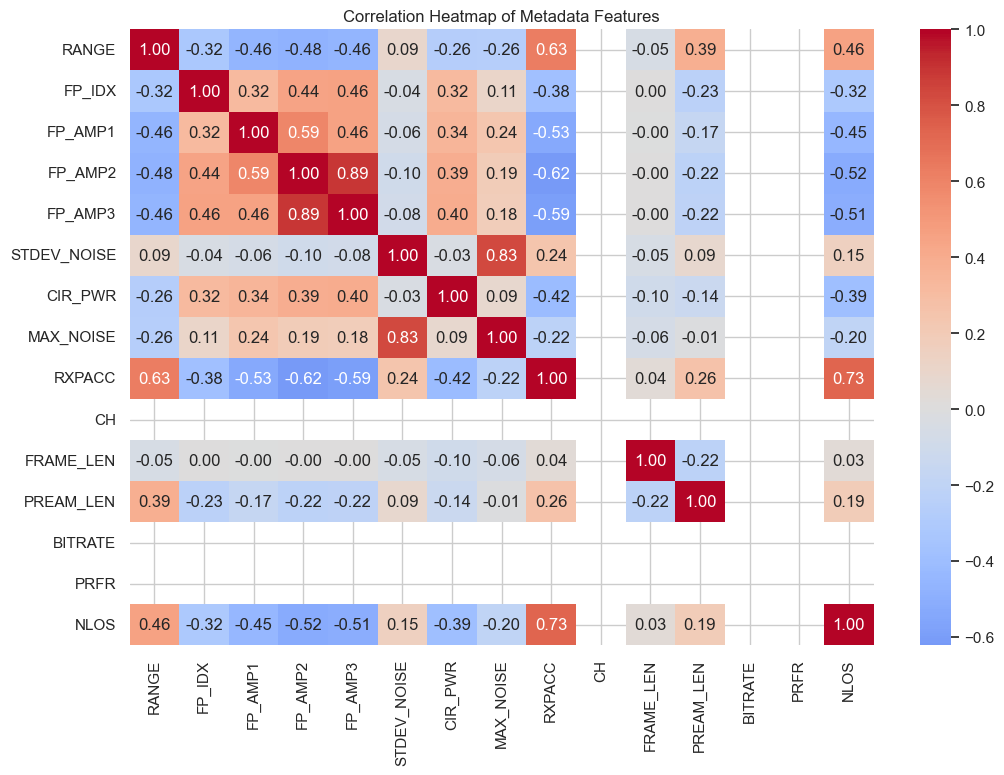

In [16]:
corr = df_raw[metadata_cols + [target_col]].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Metadata Features")
plt.savefig('results/figures/eda/06_metadata_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

The heatmap shows the full pairwise correlation structure. Below, we extract and rank each feature's individual correlation with the NLOS label to identify which metadata features have the strongest linear association with the classification target.

In [17]:
target_corr = corr[target_col].drop(target_col).sort_values(key=np.abs, ascending=False)

display(target_corr.to_frame(name="Pearson r with NLOS").style.background_gradient(cmap='RdYlGn_r', axis=0).format("{:.4f}"))

,Pearson r with NLOS
RXPACC,0.7307
FP_AMP2,-0.5249
FP_AMP3,-0.5143
RANGE,0.4568
FP_AMP1,-0.4473
CIR_PWR,-0.3923
FP_IDX,-0.3170
MAX_NOISE,-0.1982
PREAM_LEN,0.1897
STDEV_NOISE,0.1523


## 9. CIR Signal Exploration

The Channel Impulse Response (CIR) signals represent the waveform of the received UWB signal over time. Visualization of CIR samples allows observation of signal propagation patterns under LOS and NLOS conditions.

### Findings
- LOS signals typically exhibit stronger early peaks, corresponding to the direct signal path.
- NLOS signals tend to show more dispersed waveform patterns, reflecting signal reflections and multipath propagation.
- These patterns highlight the impact of environmental obstacles on signal propagation.

### Physical & Mathematical Explanation
The CIR describes the channel as a linear filter. The received signal is the convolution of the transmitted pulse $s(t)$ with the channel's impulse response:

$$h(t) = \sum_{i=1}^{N} \alpha_i \, \delta(t - \tau_i)$$

where $\alpha_i$ is the amplitude and $\tau_i$ is the propagation delay of the $i$-th multipath component.

- **LOS CIR:** The dominant component ($i=1$, the direct path) carries most of the energy. The CIR shows a sharp, isolated peak at the time-of-flight index. High kurtosis (concentrated energy) and low skewness characterise this profile.

- **NLOS CIR:** The direct path is attenuated or absent. Energy spreads across many reflected components arriving at varying delays, producing a broader, flatter waveform. This reduces kurtosis and increases the energy spread — the same statistics we use as engineered features in Section 12.

This mathematical structure is why the **1D CNN** can classify directly from the raw CIR: it learns to recognise the sharp-peak vs. spread-energy pattern without manual feature engineering, while the tabular models use the 8 statistical summaries of this same structure.

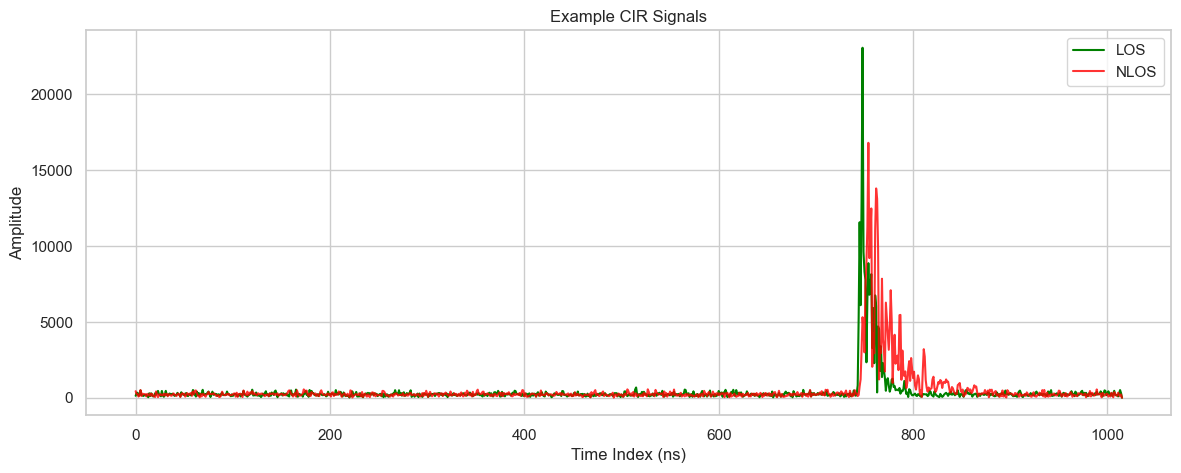

In [18]:
los_sample = df_raw[df_raw[target_col] == 0].iloc[0]
nlos_sample = df_raw[df_raw[target_col] == 1].iloc[0]

plt.figure(figsize=(14,5))
plt.plot(range(len(cir_cols)), los_sample[cir_cols].values, label="LOS", color="green")
plt.plot(range(len(cir_cols)), nlos_sample[cir_cols].values, label="NLOS", color="red", alpha=0.8)
plt.title("Example CIR Signals")
plt.xlabel("Time Index (ns)")
plt.ylabel("Amplitude")
plt.legend()
plt.savefig('results/figures/eda/07_cir_signals.png', dpi=120, bbox_inches='tight')
plt.show()

The individual LOS vs NLOS comparison shows the canonical difference: LOS has a sharp leading peak at the first-path delay, while NLOS shows a flatter, spread-out waveform. To confirm this is a consistent pattern (not just lucky sample selection), we overlay multiple waveforms from each class below.

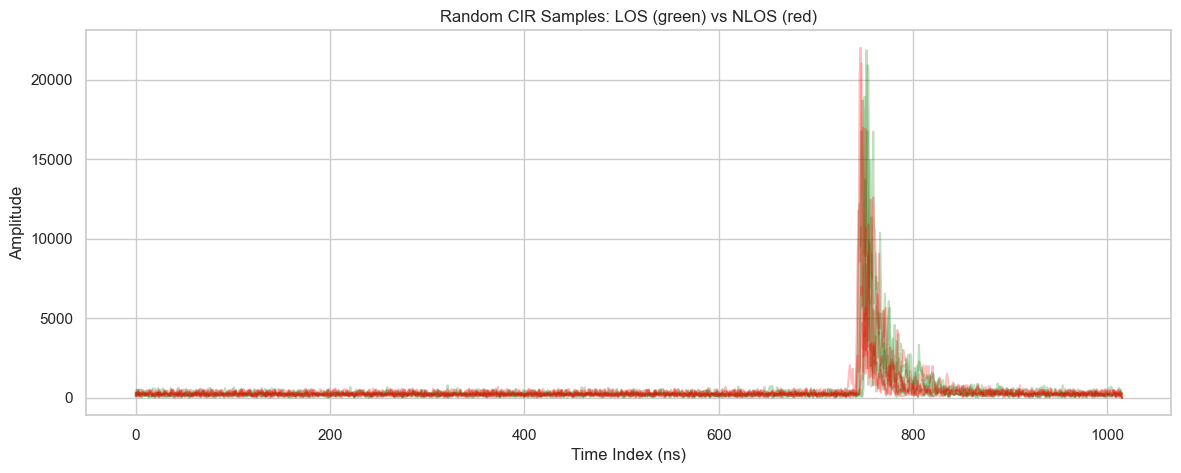

In [19]:
plt.figure(figsize=(14, 5))

for _, row in df_raw[df_raw[target_col] == 0].sample(5, random_state=42).iterrows():
    plt.plot(row[cir_cols].values, color="green", alpha=0.25)

for _, row in df_raw[df_raw[target_col] == 1].sample(5, random_state=42).iterrows():
    plt.plot(row[cir_cols].values, color="red", alpha=0.25)

plt.title("Random CIR Samples: LOS (green) vs NLOS (red)")
plt.xlabel("Time Index (ns)")
plt.ylabel("Amplitude")
plt.savefig('results/figures/eda/08_random_cir_signals.png', dpi=120, bbox_inches='tight')
plt.show()

The overlaid waveforms confirm the pattern holds consistently across multiple samples. The class-averaged CIR (mean ± 1σ) below quantifies this: we expect the LOS average to show a sharper, higher-amplitude peak concentrated at the first-path index, while NLOS spreads energy more broadly across the 1,016 time indices.

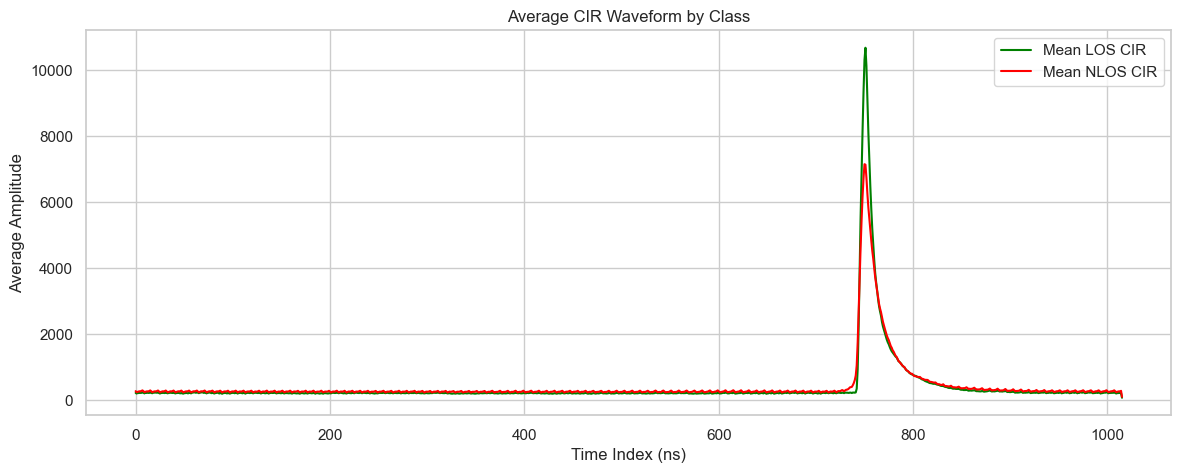

In [20]:
los_mean = df_raw[df_raw[target_col] == 0][cir_cols].mean(axis=0)
nlos_mean = df_raw[df_raw[target_col] == 1][cir_cols].mean(axis=0)

plt.figure(figsize=(14, 5))
plt.plot(los_mean.values, label="Mean LOS CIR", color="green")
plt.plot(nlos_mean.values, label="Mean NLOS CIR", color="red")
plt.title("Average CIR Waveform by Class")
plt.xlabel("Time Index (ns)")
plt.ylabel("Average Amplitude")
plt.legend()
plt.savefig('results/figures/eda/09_average_cir_waveform.png', dpi=120, bbox_inches='tight')
plt.show()

The shaded ±1σ bands show that NLOS variance is spread broadly across all time indices, while LOS variance concentrates near the first-path peak. The heatmaps below provide a 2D view of 50 randomly selected CIR waveforms from each class — each row is one measurement, colour-coded by amplitude.

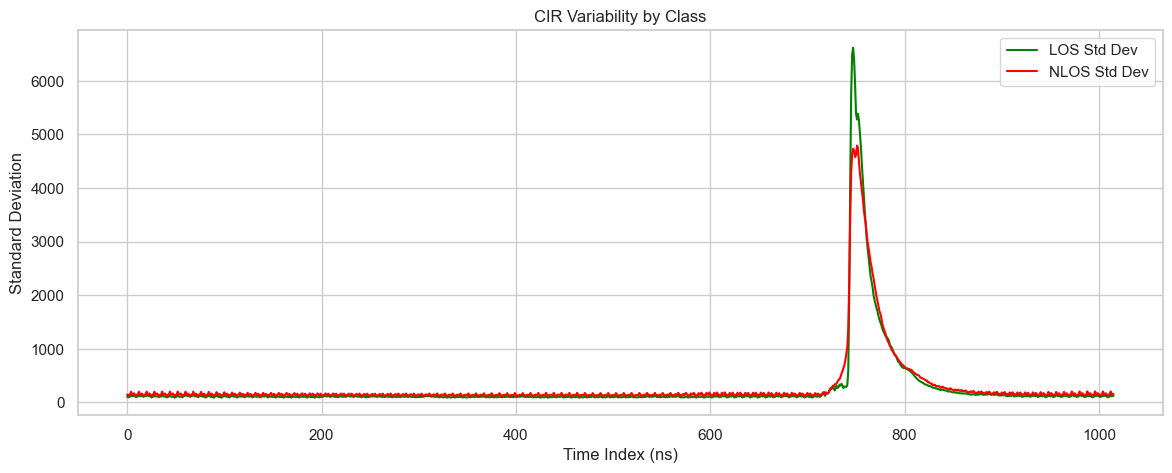

In [21]:
los_std = df_raw[df_raw[target_col] == 0][cir_cols].std(axis=0)
nlos_std = df_raw[df_raw[target_col] == 1][cir_cols].std(axis=0)

plt.figure(figsize=(14, 5))
plt.plot(los_std.values, label="LOS Std Dev", color="green")
plt.plot(nlos_std.values, label="NLOS Std Dev", color="red")
plt.title("CIR Variability by Class")
plt.xlabel("Time Index (ns)")
plt.ylabel("Standard Deviation")
plt.legend()
plt.savefig('results/figures/eda/10_cir_variability.png', dpi=120, bbox_inches='tight')
plt.show()

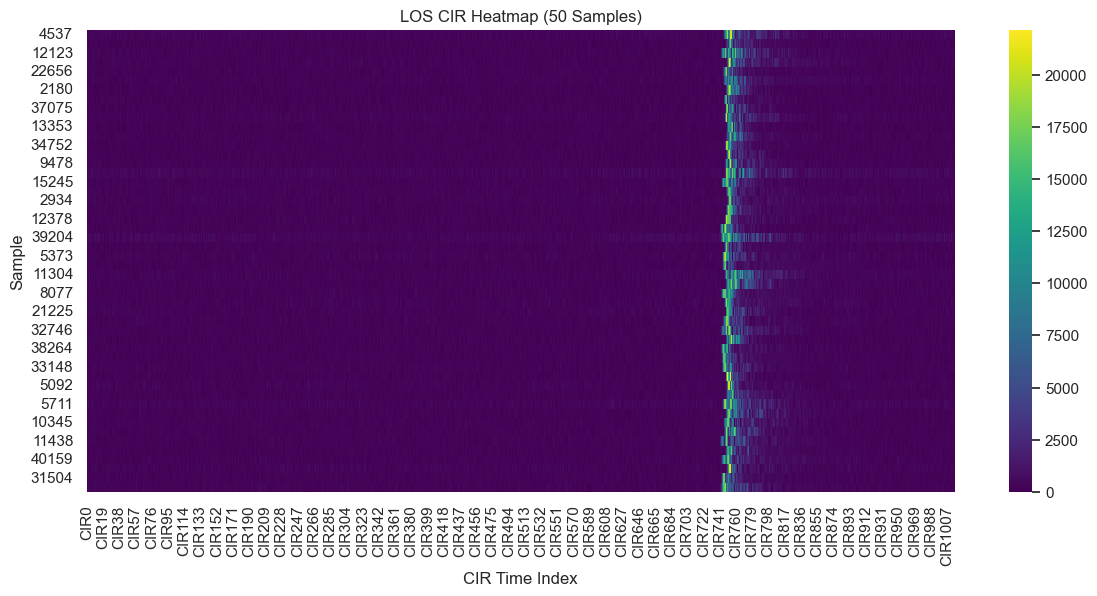

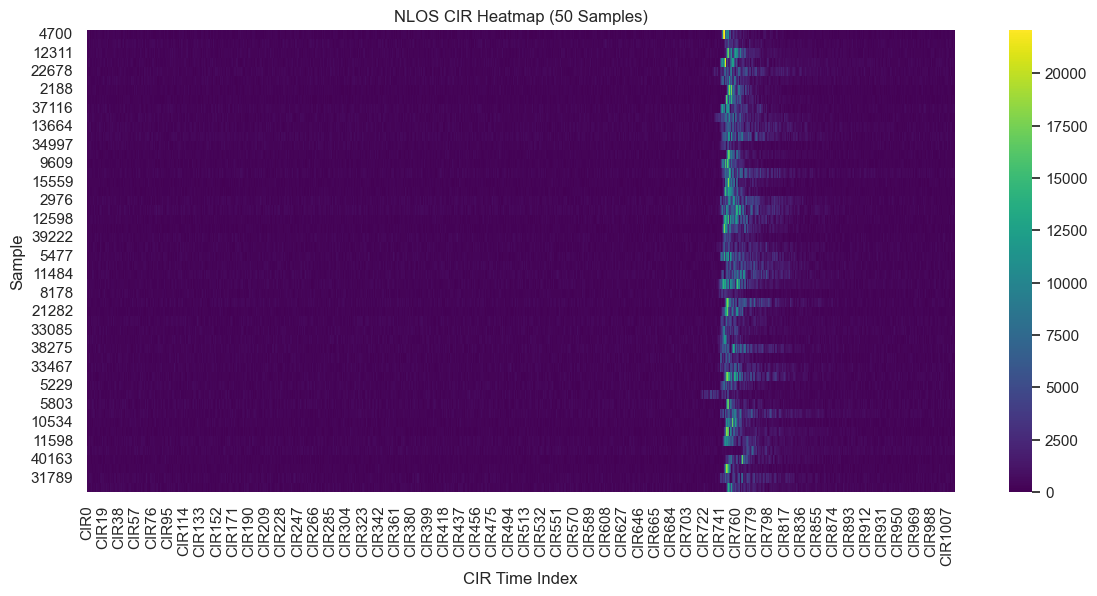

In [22]:
los_heatmap = df_raw[df_raw[target_col] == 0][cir_cols].sample(50, random_state=42)
nlos_heatmap = df_raw[df_raw[target_col] == 1][cir_cols].sample(50, random_state=42)

plt.figure(figsize=(14, 6))
sns.heatmap(los_heatmap, cmap="viridis", cbar=True)
plt.title("LOS CIR Heatmap (50 Samples)")
plt.xlabel("CIR Time Index")
plt.ylabel("Sample")
plt.show()

plt.figure(figsize=(14, 6))
sns.heatmap(nlos_heatmap, cmap="viridis", cbar=True)
plt.title("NLOS CIR Heatmap (50 Samples)")
plt.xlabel("CIR Time Index")
plt.ylabel("Sample")
plt.show()

## 10. Dimensionality Exploration with PCA

Principal Component Analysis (PCA) finds orthogonal directions of maximum variance in the data. Given a centred data matrix $X \in \mathbb{R}^{n \times p}$, PCA computes the eigendecomposition of the covariance matrix $\Sigma = \frac{1}{n-1}X^\top X$. Each eigenvector is a principal component (PC); its eigenvalue is the proportion of total variance that component explains.

We apply PCA in two separate contexts:

1. **Metadata features (11 features):** A quick sanity check — can the 11 signal statistics alone separate LOS from NLOS in 2D?
2. **CIR columns (1,016 features):** The dimensionally rich subspace. This is where dimensionality reduction actually matters — 1,016 raw samples per measurement is expensive for tabular models. The scree plot here directly justifies extracting 8 compact statistical features instead.

### Findings — Metadata PCA
- Only 53.6% of variance is explained by 2 components, confirming that the 11 metadata features alone do not cleanly separate the classes. Additional features (CIR statistics) are required.

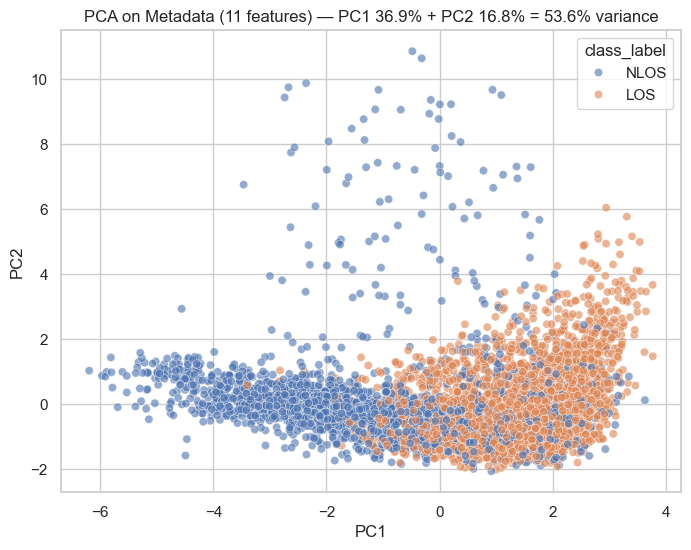

,Component,Variance explained
0,PC1,36.9%
1,PC2,16.8%
2,PC1 + PC2 total,53.6%


In [23]:
sample_df = df_raw.sample(5000, random_state=42).copy()

# metadata only — remove constant columns (CH, BITRATE, PRFR)
df_meta = sample_df[metadata_cols]
df_meta = df_meta.loc[:, df_meta.nunique() > 1]

y = sample_df[target_col]

scaler = StandardScaler()
X_pca_meta = pca_meta = PCA(n_components=2, random_state=42)
X_scaled = scaler.fit_transform(df_meta)
pca_meta  = PCA(n_components=2, random_state=42)
X_pca = pca_meta.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "class_label": y.map({0: "LOS", 1: "NLOS"})
})

ev = pca_meta.explained_variance_ratio_
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="class_label", alpha=0.6)
plt.title(f"PCA on Metadata (11 features) — PC1 {ev[0]:.1%} + PC2 {ev[1]:.1%} = {ev.sum():.1%} variance")
plt.savefig('results/figures/eda/11_pca_metadata_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

display(pd.DataFrame({
    'Component': ['PC1', 'PC2', 'PC1 + PC2 total'],
    'Variance explained': [f"{ev[0]:.1%}", f"{ev[1]:.1%}", f"{ev.sum():.1%}"]
}))

### PCA on CIR Columns (1,016 features)

The 1,016 CIR amplitude samples per measurement form a very high-dimensional feature space. The questions we want to answer:
- How many principal components are needed to capture 90% / 95% of the CIR variance?
- Does the compressed representation still separate LOS from NLOS?

The answers justify the preprocessing choice: if X components capture 95% of the CIR variance (far fewer than 1,016), then the 8 statistical features we extract are a compact and physically interpretable proxy for the dominant sources of variation in the CIR signal.

Fitting PCA on CIR columns (5,000 samples × 1,016 features)...


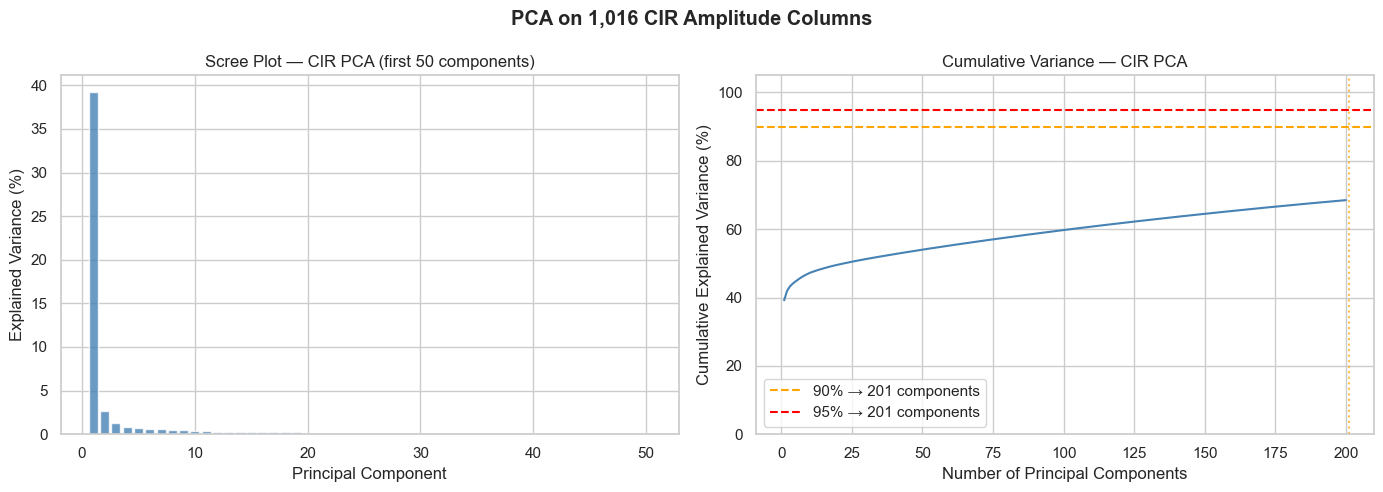

,Metric,Value
0,Components for 90% variance,201
1,Components for 95% variance,201
2,Variance from first 2 components (PC1+PC2),41.9%
3,Variance from 200 components,68.5%


In [24]:
# ── PCA on CIR columns ────────────────────────────────────────────────────────
# Sample for speed — 5,000 rows is enough for a reliable variance estimate
cir_sample_df = df_raw.sample(5000, random_state=42).copy()
cir_matrix_pca = cir_sample_df[cir_cols].values.astype(np.float32)

# Normalise by RXPACC (same as Section 12 preprocessing)
rxpacc_pca = cir_sample_df['RXPACC'].values.reshape(-1, 1).astype(np.float32)
cir_matrix_pca = cir_matrix_pca / (rxpacc_pca + 1e-8)

# Standardise before PCA
scaler_cir = StandardScaler()
cir_scaled = scaler_cir.fit_transform(cir_matrix_pca)

# Fit PCA with 200 components
print("Fitting PCA on CIR columns (5,000 samples × 1,016 features)...")
pca_cir_full = PCA(n_components=200, random_state=42, svd_solver='randomized')
pca_cir_full.fit(cir_scaled)

evr = pca_cir_full.explained_variance_ratio_
cumvar = np.cumsum(evr)

# Find thresholds
n_90 = int(np.searchsorted(cumvar, 0.90)) + 1
n_95 = int(np.searchsorted(cumvar, 0.95)) + 1

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (bar) — first 50 for readability
axes[0].bar(range(1, 51), evr[:50] * 100, color='steelblue', alpha=0.8)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot — CIR PCA (first 50 components)")

# Cumulative variance curve
axes[1].plot(range(1, 201), cumvar * 100, linewidth=1.5, color='steelblue')
axes[1].axhline(90, color='orange', linestyle='--', label=f'90% → {n_90} components')
axes[1].axhline(95, color='red', linestyle='--', label=f'95% → {n_95} components')
axes[1].axvline(n_90, color='orange', linestyle=':', alpha=0.7)
axes[1].set_xlabel("Number of Principal Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Cumulative Variance — CIR PCA")
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.suptitle("PCA on 1,016 CIR Amplitude Columns", fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/eda/12_cir_pca_scree.png', dpi=120, bbox_inches='tight')
plt.show()

# Summary table instead of print statements
display(pd.DataFrame({
    'Metric': [
        'Components for 90% variance',
        'Components for 95% variance',
        'Variance from first 2 components (PC1+PC2)',
        'Variance from 200 components'
    ],
    'Value': [n_90, n_95, f"{cumvar[1]:.1%}", f"{cumvar[-1]:.1%}"]
}))

The scree plot confirms rapid drop-off after the first component, followed by a long flat tail — characteristic of high-dimensional data with one dominant mode (overall signal energy). The summary table shows how many components are needed to reach the standard variance thresholds. The 2D scatter below tests whether PC1+PC2 alone provide any LOS/NLOS class separation.

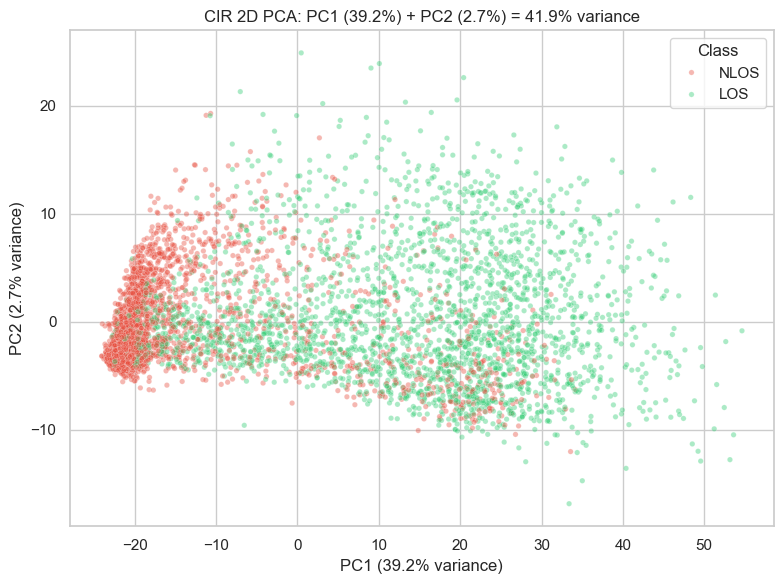

In [25]:
# ── 2D CIR PCA scatter — LOS vs NLOS separation ──────────────────────────────
pca_cir_2d = PCA(n_components=2, random_state=42)
cir_2d = pca_cir_2d.fit_transform(cir_scaled)

pca_cir_df = pd.DataFrame({
    "PC1": cir_2d[:, 0],
    "PC2": cir_2d[:, 1],
    "Class": cir_sample_df[target_col].map({0: "LOS", 1: "NLOS"}).values,
})

ev2 = pca_cir_2d.explained_variance_ratio_
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_cir_df, x="PC1", y="PC2", hue="Class",
                palette={"LOS": "#2ecc71", "NLOS": "#e74c3c"}, alpha=0.4, s=15)
plt.title(f"CIR 2D PCA: PC1 ({ev2[0]:.1%}) + PC2 ({ev2[1]:.1%}) = {ev2.sum():.1%} variance")
plt.xlabel(f"PC1 ({ev2[0]:.1%} variance)")
plt.ylabel(f"PC2 ({ev2[1]:.1%} variance)")
plt.tight_layout()
plt.savefig('results/figures/eda/13_cir_pca_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

### Findings — CIR PCA

The scree plot and cumulative variance curve reveal important properties of the CIR signal:

- **Strong first component (~39% variance):** PC1 dominates — this component likely captures the overall signal energy level, which differs systematically between LOS and NLOS due to path loss. The dramatic drop after PC2 confirms a single dominant mode.

- **Long tail — high intrinsic dimensionality:** 200 components explain only ~68% of variance. Unlike image data, the CIR is mostly noise with localised signal peaks whose positions vary between samples (FP_IDX ranges from 707–848 across the dataset). This position jitter means adjacent CIR samples are largely uncorrelated, spreading variance across many dimensions.

- **Implication for feature engineering:** Because PCA cannot compress the CIR into a small number of global components, we need *domain-aware* feature extraction rather than unsupervised compression. The 8 statistical features (max, energy, kurtosis, etc.) capture physically interpretable properties of the waveform that generalise across the position-variable CIR structure. The 1D CNN avoids this problem entirely by learning translation-invariant patterns directly.

- **2D projection:** The next cell shows partial class separation even in 2D (PC1+PC2 = ~42% variance), confirming that CIR shape carries discriminative signal even in the compressed representation.

## 11. Key EDA Findings Summary

- The merged dataset contains all **7 dataset parts** and is **balanced** between **LOS and NLOS samples**.
- Data quality checks confirm that the dataset contains **no missing values** and **no duplicate records**.
- Metadata features describing signal strength and noise exhibit different distributions across LOS and NLOS conditions. Physical multipath theory explains why: NLOS signals show higher noise (interference from multiple reflected paths) and lower first-path amplitudes (signal attenuation through obstacles).
- Correlation analysis highlights that **RXPACC** has the strongest association with the target — lower preamble accumulation indicates a degraded NLOS channel.
- CIR waveform visualization confirms the expected LOS (sharp peak) vs. NLOS (broad, spread) pattern, consistent with the channel impulse response model $h(t) = \sum_i \alpha_i \delta(t - \tau_i)$.
- **PCA on 11 metadata features** captures only 53.6% of variance in 2 components — metadata alone is insufficient for clean separation.
- **PCA on 1,016 CIR columns** shows that PC1 (~39% variance) separates LOS from NLOS along the energy axis, with visible class clustering in 2D. However, the high intrinsic dimensionality of the CIR (200 components explain only ~68% of variance) motivates domain-aware feature extraction rather than unsupervised compression.

In [26]:
eda_overview = pd.DataFrame({
    "dtype": df_raw.dtypes,
    "missing": df_raw.isna().sum(),
    "n_unique": df_raw.nunique(),
    "sample_value": df_raw.iloc[0]
})

eda_overview.head(30)

,dtype,missing,n_unique,sample_value
NLOS,float64,0,2,0.0
RANGE,float64,0,1160,3.9
FP_IDX,float64,0,76,745.0
FP_AMP1,float64,0,16693,18712.0
FP_AMP2,float64,0,16533,10250.0
FP_AMP3,float64,0,16614,11576.0
STDEV_NOISE,float64,0,75,64.0
CIR_PWR,float64,0,16591,11855.0
MAX_NOISE,float64,0,3056,967.0
RXPACC,float64,0,725,611.0


## 12. Data Preprocessing

### Data Cleaning

There are no missing values — the DWM1000 hardware always populates every output field. No duplicate rows were found. Amplitude outliers from strong LOS signals are kept since they reflect real measurements, not sensor faults. The dataset is already balanced (21,000 LOS, 21,000 NLOS) so no resampling was needed.

### Removing Zero-Variance Features

Columns `CH`, `BITRATE`, and `PRFR` are constant across all 42,000 samples — they carry no information and are dropped. `dataset_part` and `class_label` are also removed since they are metadata, not signal measurements.

### CIR Dimensionality Reduction

The raw CIR has 1,016 amplitude samples per measurement. Using all 1,016 directly would be computationally expensive and create a very high-dimensional feature space. We extract 8 statistical descriptors that capture the key differences between LOS and NLOS channel profiles:

| Feature | Physical Meaning |
|---|---|
| `cir_mean` | Average amplitude |
| `cir_std` | Signal spread |
| `cir_max` | Peak amplitude |
| `cir_peak_idx` | Index of dominant path |
| `cir_energy` | Total signal energy |
| `cir_kurtosis` | Peak sharpness — LOS has a sharp concentrated peak (high kurtosis); NLOS spreads energy across multiple reflections (lower kurtosis) |
| `cir_skewness` | Waveform asymmetry |
| `cir_rms` | Root mean square amplitude |

In [27]:
df_raw = df_raw.reset_index(drop=True).copy()
df_raw['row_id'] = df_raw.index

# ── Drop zero-variance & metadata columns ─────────────────────────────────────
TARGET_CLASS = 'NLOS'
TARGET_REG   = 'RANGE'
DROP_COLS    = ['CH', 'BITRATE', 'PRFR', 'dataset_part', 'class_label']

existing_drop = [c for c in DROP_COLS if c in df_raw.columns]
df_preprocess = df_raw.drop(columns=existing_drop)

METADATA_FEATURES = [
    'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
    'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'FRAME_LEN', 'PREAM_LEN'
]

cir_cols_clean = sorted(
    [c for c in df_preprocess.columns if c.startswith('CIR') and c[3:].isdigit()],
    key=lambda x: int(x[3:])
)

display(pd.DataFrame({
    'Step': ['Columns dropped (zero-variance + metadata)', 'Shape before', 'Shape after',
             'Remaining metadata features', 'CIR columns retained'],
    'Value': [str(existing_drop), str(df_raw.shape), str(df_preprocess.shape),
              len(METADATA_FEATURES), len(cir_cols_clean)]
}))

,Step,Value
0,Columns dropped (zero-variance + metadata),"['CH', 'BITRATE', 'PRFR', 'dataset_part', 'class_label']"
1,Shape before,"(42000, 1034)"
2,Shape after,"(42000, 1029)"
3,Remaining metadata features,11
4,CIR columns retained,1016


With zero-variance columns removed, we now extract **8 statistical features** from the 1,016-point CIR waveform. The CIR values are first divided by `RXPACC` — the number of preamble symbols accumulated by the DW1000 receiver — which normalises amplitude across measurements with different accumulation counts (a hardware requirement documented in the DW1000 user manual).

In [28]:
# ── CIR statistical feature extraction ───────────────────────────────────────
print("Extracting CIR statistical features (this may take ~30 seconds)...")

cir_matrix = df_preprocess[cir_cols_clean].values.astype(np.float32)

# Normalise by RXPACC — makes amplitude values comparable across measurements
# with different preamble accumulation counts (DW1000 hardware requirement)
rxpacc_vals = df_preprocess['RXPACC'].values.reshape(-1, 1).astype(np.float32)
cir_matrix  = cir_matrix / (rxpacc_vals + 1e-8)

cir_stats = pd.DataFrame({
    'cir_mean'      : np.mean(cir_matrix, axis=1),
    'cir_std'       : np.std(cir_matrix, axis=1),
    'cir_max'       : np.max(cir_matrix, axis=1),
    'cir_peak_idx'  : np.argmax(cir_matrix, axis=1).astype(float),
    'cir_energy'    : np.sum(cir_matrix ** 2, axis=1),
    'cir_kurtosis'  : kurtosis(cir_matrix, axis=1),
    'cir_skewness'  : skew(cir_matrix, axis=1),
    'cir_rms'       : np.sqrt(np.mean(cir_matrix ** 2, axis=1)),
})

cir_stats['row_id'] = df_preprocess['row_id'].values

print(f"Done — {cir_stats.shape[0]:,} rows × {cir_stats.shape[1]-1} CIR features extracted.")
cir_stats.describe().round(4)

Extracting CIR statistical features (this may take ~30 seconds)...
Done — 42,000 rows × 8 CIR features extracted.


,cir_mean,cir_std,cir_max,cir_peak_idx,cir_energy,cir_kurtosis,cir_skewness,cir_rms,row_id
count,42000.0000,42000.0000,42000.0000,42000.0000,42000.0000,42000.0000,42000.0000,42000.0000,42000.00
mean,0.8499,2.3825,36.2952,750.8763,8589.3389,111.5764,9.5158,2.5375,20999.50
std,0.3900,1.3796,22.5948,5.1505,7615.9517,48.4045,2.2209,1.4196,12124.50
min,0.2887,0.2574,2.6063,716.0000,164.0471,-1.1488,-0.4871,0.4018,0.00
25%,0.4645,0.9883,13.6804,748.0000,1233.7841,73.3172,7.8494,1.1020,10499.75
50%,0.8138,2.3661,35.1647,750.0000,6361.2368,106.6917,9.5021,2.5022,20999.50
75%,1.2038,3.6783,57.1029,753.0000,15291.0461,145.0215,11.1939,3.8795,31499.25
max,1.8958,5.0846,86.7903,950.0000,28176.9062,326.5891,16.7402,5.2662,41999.00


### CIR Statistical Feature Separation by Class

The 8 engineered CIR features bridge EDA and modelling. Here we visualise how well each feature separates LOS from NLOS — this directly validates the feature engineering choice before training any model.

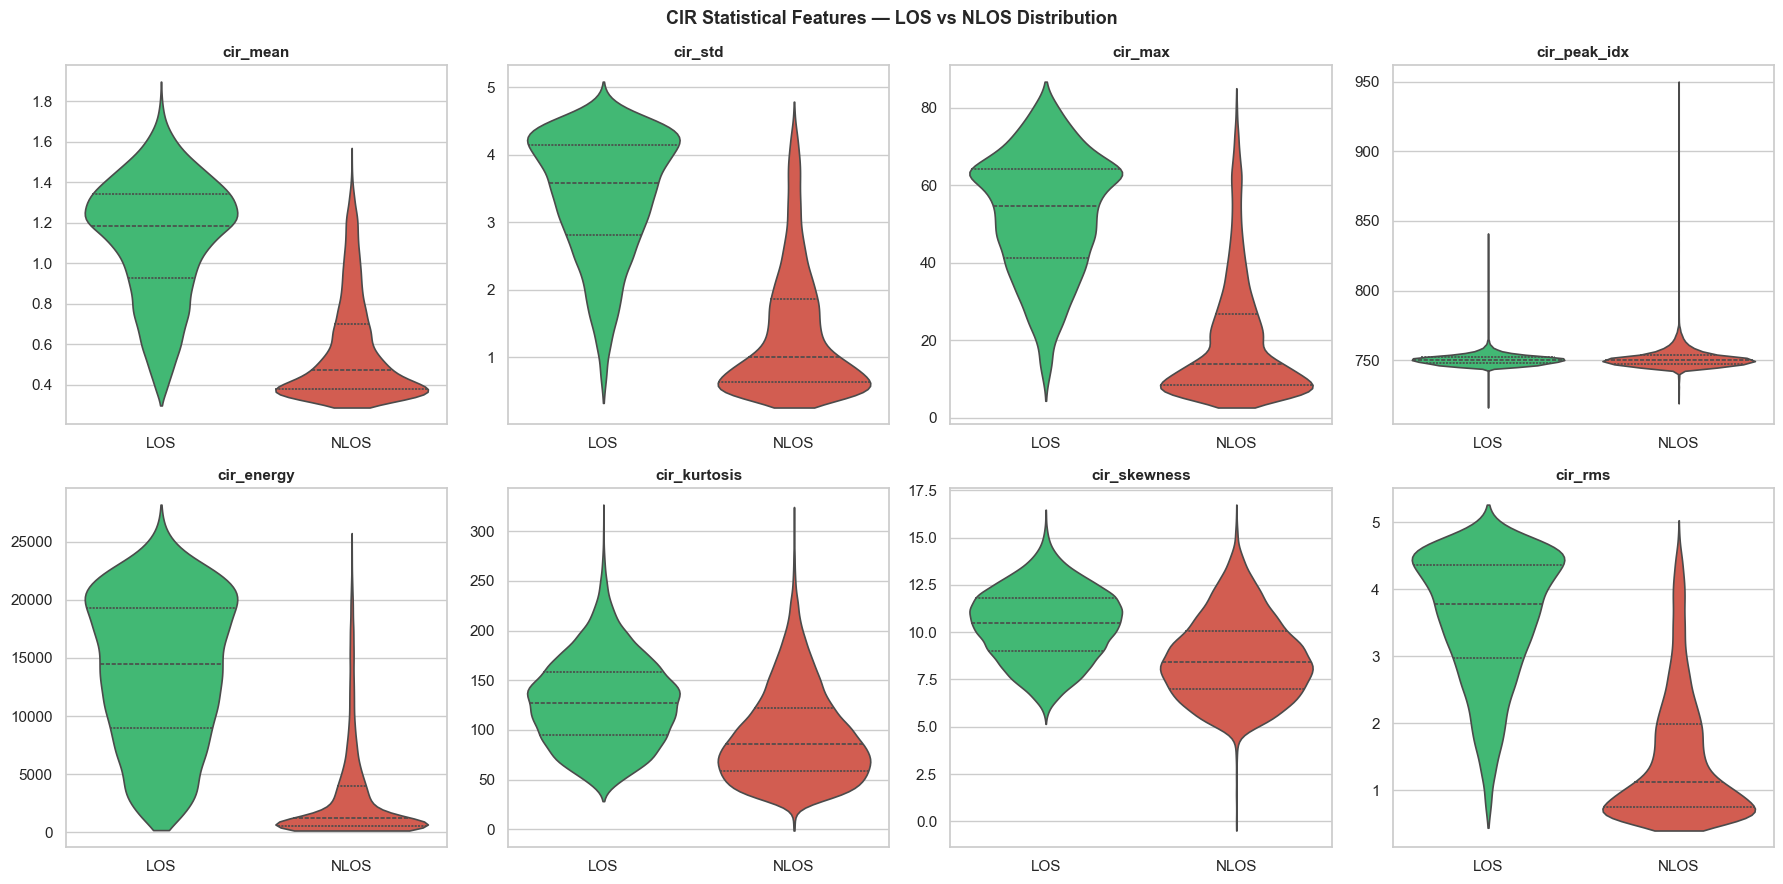

,Feature,Separation Index (Cohen's d ≈)
0,cir_rms,2.763
1,cir_std,2.750
2,cir_max,2.580
3,cir_mean,2.580
4,cir_energy,2.493
5,cir_skewness,1.019
6,cir_kurtosis,0.916
7,cir_peak_idx,0.000


In [29]:
# ── Violin plots of 8 CIR statistical features by LOS/NLOS ──────────────────
cir_feat_names = ['cir_mean', 'cir_std', 'cir_max', 'cir_peak_idx',
                  'cir_energy', 'cir_kurtosis', 'cir_skewness', 'cir_rms']

# Combine CIR stats with target label for plotting
plot_df = cir_stats[cir_feat_names].copy()
plot_df['Class'] = df_preprocess['NLOS'].map({0: 'LOS', 1: 'NLOS'}).values

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

palette = {'LOS': '#2ecc71', 'NLOS': '#e74c3c'}

for i, feat in enumerate(cir_feat_names):
    sns.violinplot(
        data=plot_df, x='Class', y=feat, ax=axes[i],
        palette=palette, inner='quartile', cut=0, linewidth=1.2
    )
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.suptitle("CIR Statistical Features — LOS vs NLOS Distribution", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/eda/14_cir_features_violin.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Separation index table (replaces terminal print loop) ────────────────────
sep_data = []
for feat in cir_feat_names:
    los_v  = plot_df.loc[plot_df['Class'] == 'LOS',  feat]
    nlos_v = plot_df.loc[plot_df['Class'] == 'NLOS', feat]
    pooled_std = (los_v.std() + nlos_v.std()) / 2
    sep = abs(los_v.median() - nlos_v.median()) / (pooled_std + 1e-9)
    sep_data.append({'Feature': feat, 'Separation Index (Cohen\'s d ≈)': round(sep, 3)})

display(
    pd.DataFrame(sep_data)
      .sort_values("Separation Index (Cohen's d ≈)", ascending=False)
      .reset_index(drop=True)
)

### Findings — CIR Feature Separation

The separation index (median difference ÷ pooled std, similar to Cohen's d) shows which features best discriminate LOS from NLOS:

| Feature | Separation | Interpretation |
|---|---|---|
| `cir_rms` | **2.76** | Strong — RMS amplitude is directly tied to total received energy; LOS signals carry more energy via the direct path |
| `cir_std` | **2.75** | Strong — amplitude spread is higher in LOS where the dominant peak creates large variance relative to the noise floor |
| `cir_mean`, `cir_max` | **~2.58** | Strong — same energy argument; LOS amplitude is systematically higher |
| `cir_energy` | **2.49** | Strong — sum of squared amplitudes; physically equivalent to total signal power |
| `cir_skewness` | **1.02** | Moderate — LOS waveforms are more right-skewed (sharp peak at the direct path delay) |
| `cir_kurtosis` | **0.92** | Moderate — LOS CIR has a sharper, more peaked distribution, but high variance limits separation |
| `cir_peak_idx` | **0.00** | No separation — the peak index (related to distance, not LOS/NLOS) varies with range, not channel condition |

**Key takeaway:** The energy-based features (RMS, std, max, mean, energy) show the clearest separation because the core difference between LOS and NLOS is the energy level of the received signal. `cir_peak_idx` is correctly excluded from classification (it encodes range, not channel condition) but remains useful for regression.

## 13. Export Preprocessed Data

The preprocessed dataset (11 metadata features + 8 CIR statistical features + label + regression target) is exported as a single CSV. This separation of concerns keeps the EDA notebook exploratory and the ML notebook focused on model training — the ML notebook always starts from the same well-defined preprocessed state.

In [30]:
# Verify row IDs align before concatenating — a mismatch would silently join wrong rows
assert (df_preprocess['row_id'].values == cir_stats['row_id'].values).all(), \
    "Row ID mismatch between df_preprocess and cir_stats!"
print("✅ Row IDs verified — safe to concatenate.")

✅ Row IDs verified — safe to concatenate.


In [31]:
# Append CIR statistical features
df_export = pd.concat(
    [
        df_preprocess.reset_index(drop=True),
        cir_stats.drop(columns=['row_id']).reset_index(drop=True)
    ],
    axis=1
)

# Drop temporary row_id before export
if 'row_id' in df_export.columns:
    df_export = df_export.drop(columns=['row_id'])

# Export
data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)

output_file = data_dir / "uwb_preprocessed_for_ml.csv"
df_export.to_csv(output_file, index=False)

display(pd.DataFrame({
    'Export detail': ['File', 'Shape', 'Columns: metadata features', 'Columns: CIR statistics', 'Columns: targets'],
    'Value': [str(output_file.resolve()), str(df_export.shape),
              len(METADATA_FEATURES), len(cir_feat_names), '2 (NLOS, RANGE)']
}))
print("✅ Export complete.")

,Export detail,Value
0,File,C:\Users\angcl\Documents\School\Uni\CSC3105_Group14\data\uwb_preprocessed_for_ml.csv
1,Shape,"(42000, 1036)"
2,Columns: metadata features,11
3,Columns: CIR statistics,8
4,Columns: targets,"2 (NLOS, RANGE)"


✅ Export complete.
